
<center>
<a href="http://www.insa-toulouse.fr/" ><img src="http://www.math.univ-toulouse.fr/~besse/Wikistat/Images/logo-insa.jpg" style="float:left; max-width: 120px; display: inline" alt="INSA"/></a> 

</center>

# Machine Learning Project
MoraGarcia Carmen, (i don't know your last name) Léo, Dubouchet Chloé et Perrin Alicia


## Introduction

The data is taken from the KAGGLE competition website; it is the data set "Cardivascular Disease Risk
Prediction Dataset" available here: https://www.kaggle.com/datasets/bertnardomariouskono/cardiovasculardisease-risk-prediction-dataset.


This dataset contains 15,000 synthetic patient medical records specifically designed to predict the risk of
cardiovascular disease. Although synthetic, the data is generated using medical heuristics to ensure realistic
correlations between variables, such as the relationship between age, BMI, and blood pressure. The dataset
includes 19 variables for 15,000 patients.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimpy import skim
import seaborn as sns
from pandas.plotting import scatter_matrix
from math import sqrt

## 1. Exploratory data analysis

## a. Read the table of data

In [23]:
df = pd.read_csv("archive/healthcare_synthetic_data.csv", sep=",")

We start by checking the nature of the different variables and their encoding.

In [38]:
df['Gender'] = df['Gender'].astype('category')
df['Gender'] = df['Gender'].cat.rename_categories(['Woman', 'Man'])
df['Smoking_Status'] = df['Smoking_Status'].astype('category')
df['Smoking_Status'] = df['Smoking_Status'].cat.rename_categories(['Non_Smoker', 'Smoker'])
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].astype('category')
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].cat.rename_categories(['Non', 'Moderate', 'Heavy'])
df['Physical_Activity_Level'] = df['Physical_Activity_Level'].astype('category')
df['Family_History'] = df['Family_History'].astype('category')
df['Family_History'] = df['Family_History'].cat.rename_categories(['No', 'Yes'])
df['Heart_Disease_Risk'] = df['Heart_Disease_Risk'].astype('category')
df['Heart_Disease_Risk'] = df['Heart_Disease_Risk'].cat.rename_categories(['Low', 'High'])
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                Categories                                       │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━━━┓                              │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables   ┃                              │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━━━┩                              │
│ │ Number of rows    │ 15000  │ │ int64       │ 9     │ │ Gender                  │                              │
│ │ Number of columns │ 19     │ │ category    │ 6     │ │ Smoking_Status          │                              │
│ └───────────────────┴────────┘ │ float64     │ 3     │ │ Alcohol_Consumption     │                              │
│                                │ string      │ 1     │ │ Physical_Activity_Level │                              │
│                                └─────────────┴───────┘ │ Family_History          │                              │
│                                                        │ Heart_Disease_Risk      │                              │
│                                                        └─────────────────────────┘                              │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                 ┃ NA  ┃ NA %  ┃ mean   ┃ sd      ┃ p0     ┃ p25    ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ Age                    │   0 │     0 │  54.54 │   11.88 │     25 │     46 │    55 │    63 │    85 │ ▁▅▇▇▅▁ │  │
│ │ Height_cm              │   0 │     0 │  165.3 │   9.186 │  138.5 │  158.5 │ 164.7 │   172 │ 198.1 │  ▅▇▆▂  │  │
│ │ Systolic_BP            │   0 │     0 │  135.1 │   11.26 │     90 │    127 │   135 │   143 │   182 │  ▂▇▇▁  │  │
│ │ Diastolic_BP           │   0 │     0 │  90.54 │   8.443 │     60 │     85 │    91 │    96 │   120 │  ▂▇▇▃  │  │
│ │ Cholesterol_Total      │   0 │     0 │  216.2 │   22.69 │    127 │    201 │   216 │   231 │   303 │  ▂▇▇▂  │  │
│ │ Cholesterol_LDL        │   0 │     0 │  140.4 │   17.91 │     70 │    128 │   140 │   152 │   210 │  ▂▇▇▂  │  │
│ │ Cholesterol_HDL        │   0 │     0 │  43.31 │   5.963 │     20 │     39 │    43 │    47 │    68 │  ▂▇▇▂  │  │
│ │ Fasting_Blood_Sugar    │   0 │     0 │  99.67 │   15.26 │     60 │     89 │    99 │   110 │   167 │  ▁▆▇▃  │  │
│ │ Stress_Level           │   0 │     0 │  5.504 │   2.874 │      1 │      3 │   5.5 │     8 │    10 │ ▇▃▇▃▇▇ │  │
│ │ Sleep_Hours            │   0 │     0 │  6.506 │   1.213 │      4 │      6 │     7 │     7 │    10 │ ▁▅▇▇▅▁ │  │
│ │ R_Weight_kg            │   0 │     0 │  8.637 │  0.8044 │  5.805 │  8.075 │ 8.597 │  9.16 │ 12.25 │  ▃▇▅▁  │  │
│ │ R_BMI                  │   0 │     0 │  5.224 │  0.3917 │  3.808 │   4.95 │ 5.215 │ 5.477 │  6.79 │  ▂▇▆▁  │  │
│ └────────────────────────┴─────┴───────┴────────┴─────────┴────────┴────────┴───────┴───────┴───────┴────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓  │
│ ┃ column                                        ┃ NA      ┃ NA %        ┃ ordered           ┃ unique         ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩  │
│ │ Gender                                        │       0 │           0 │ False             │              2 │  │
│ │ Smoking_Status                                │     

Among the 19 variables in the data set there is 12 quantitatives and 6 qualitatives variables. The last one is the ID of patients, which we will not use in our study.

## b. Unidimensional descriptive analysis of the data.

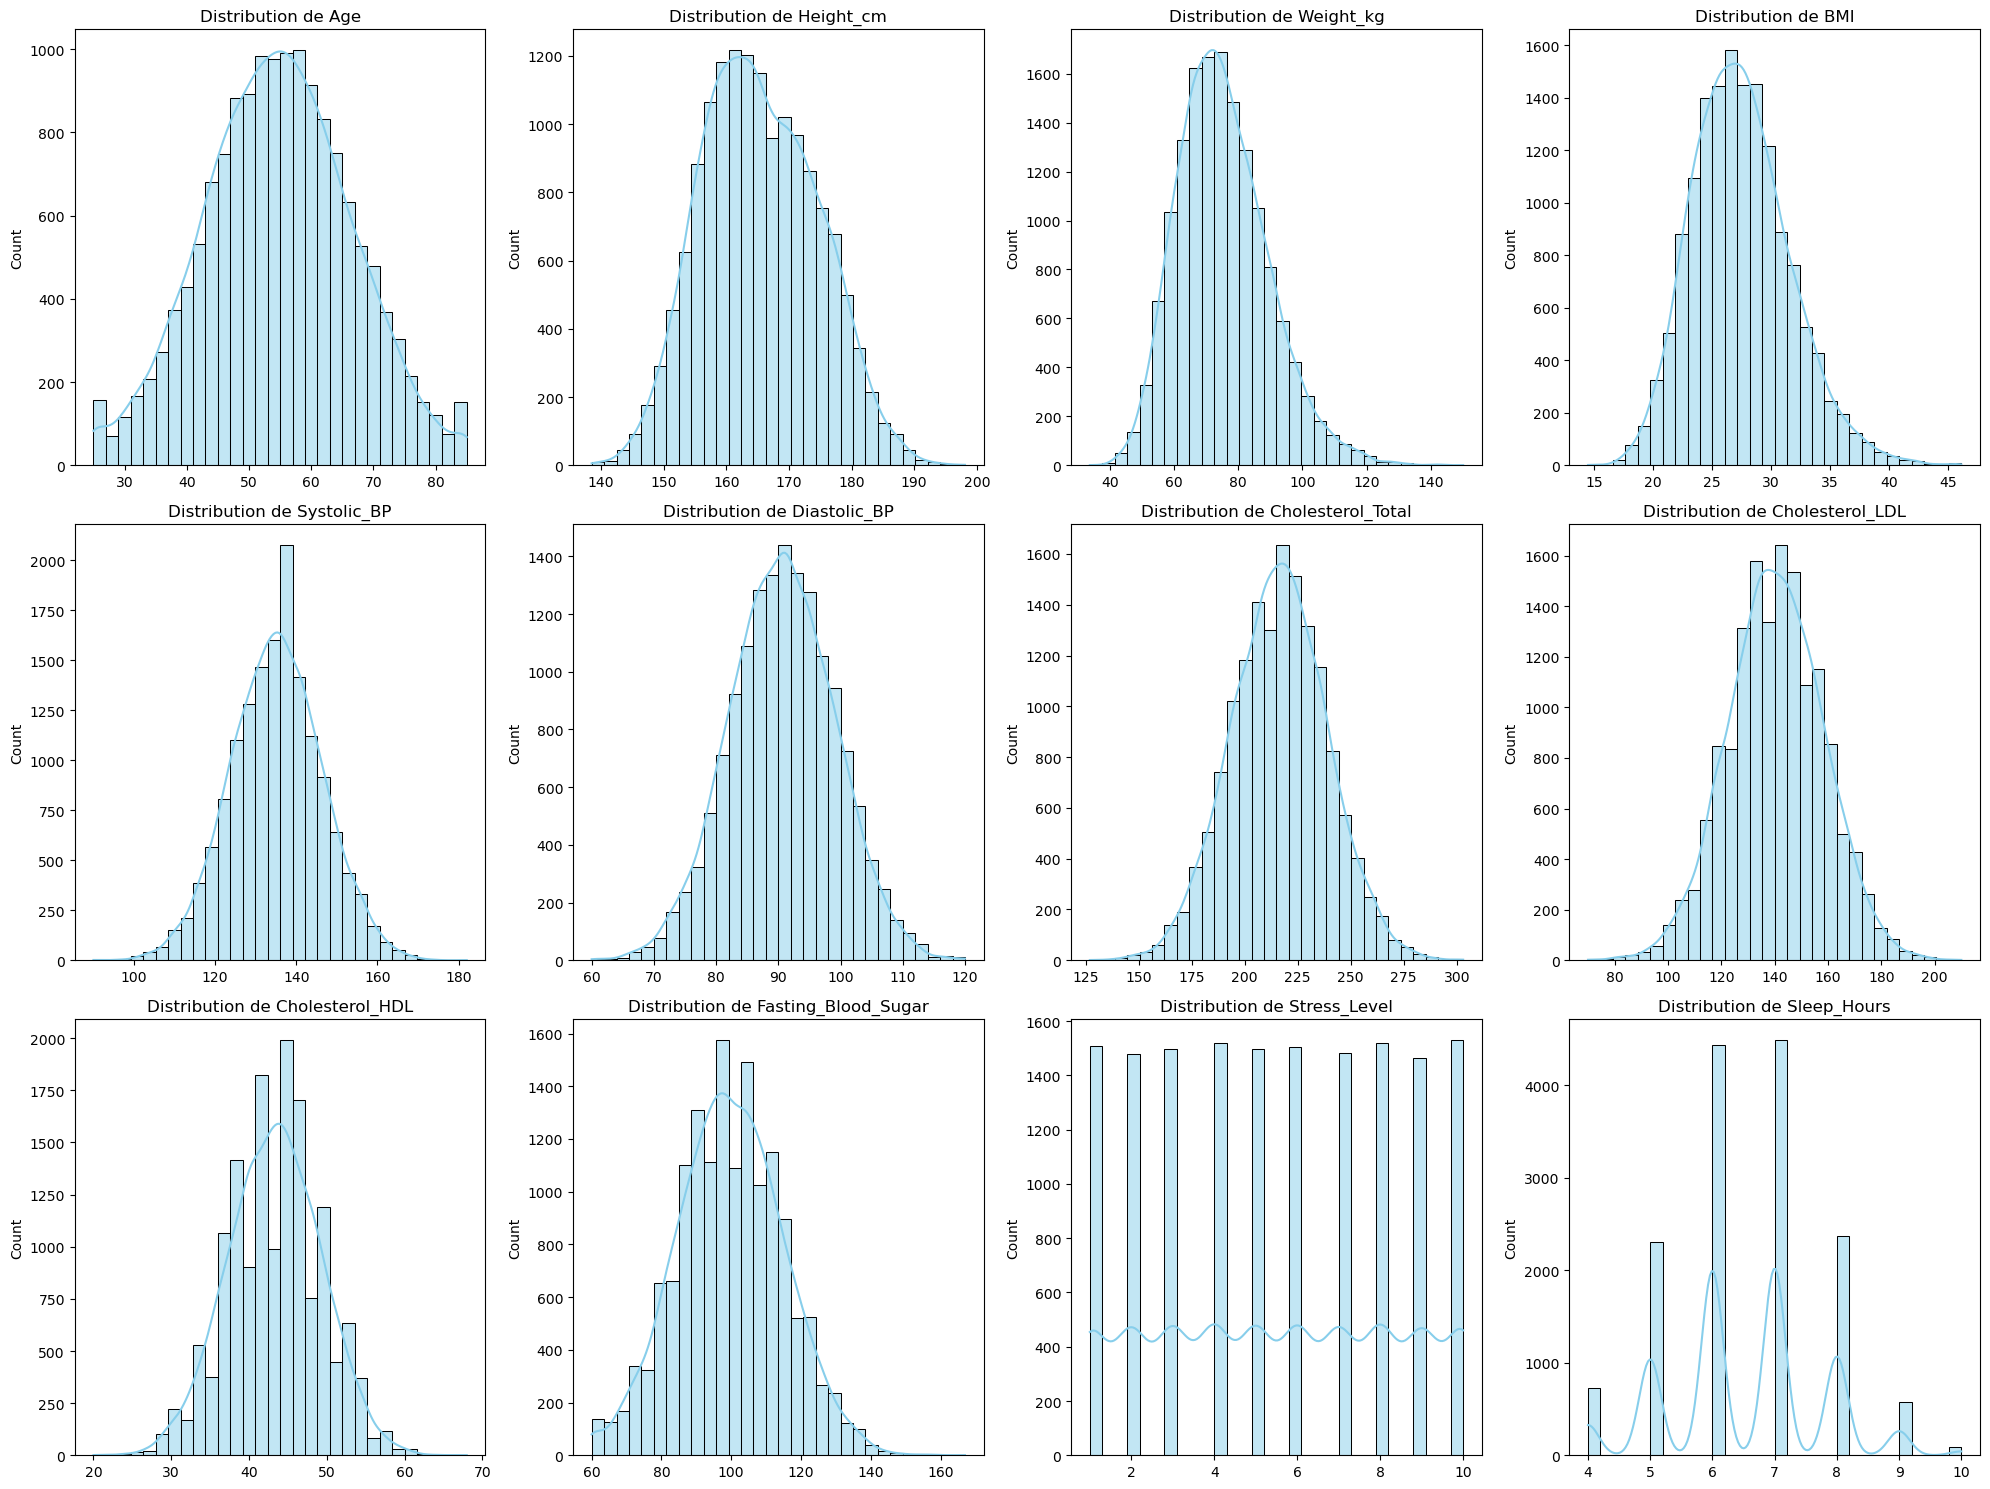

In [25]:
variables = ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL','Cholesterol_HDL', 'Fasting_Blood_Sugar', 'Stress_Level', 'Sleep_Hours']
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten() 

for i, col in enumerate(variables):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', bins=30)
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

Due to the non-Gaussian nature of the weight and BMI distributions, we explored alternative transformations. A square root transformation was adopted to address the observed right skewness.

In [26]:
df["R_Weight_kg"]=df["Weight_kg"].map(lambda x: sqrt(x))
df["R_BMI"]=df["BMI"].map(lambda x: sqrt(x))
variables = ['Age', 'Height_cm', 'R_Weight_kg', 'R_BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL','Cholesterol_HDL', 'Fasting_Blood_Sugar', 'Stress_Level', 'Sleep_Hours']

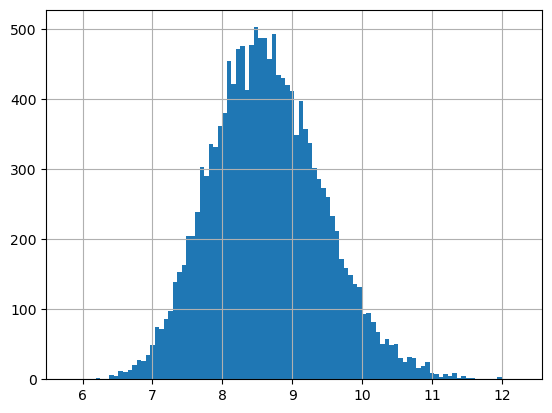

In [27]:
df["R_Weight_kg"].hist(bins=100)
plt.show()

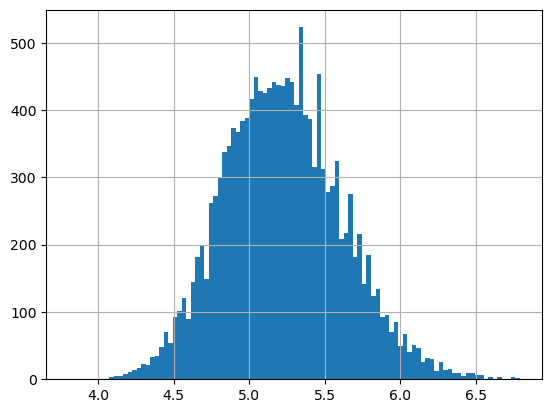

In [28]:
df["R_BMI"].hist(bins=100)
plt.show()

In [29]:
del df['BMI']
del df['Weight_kg']

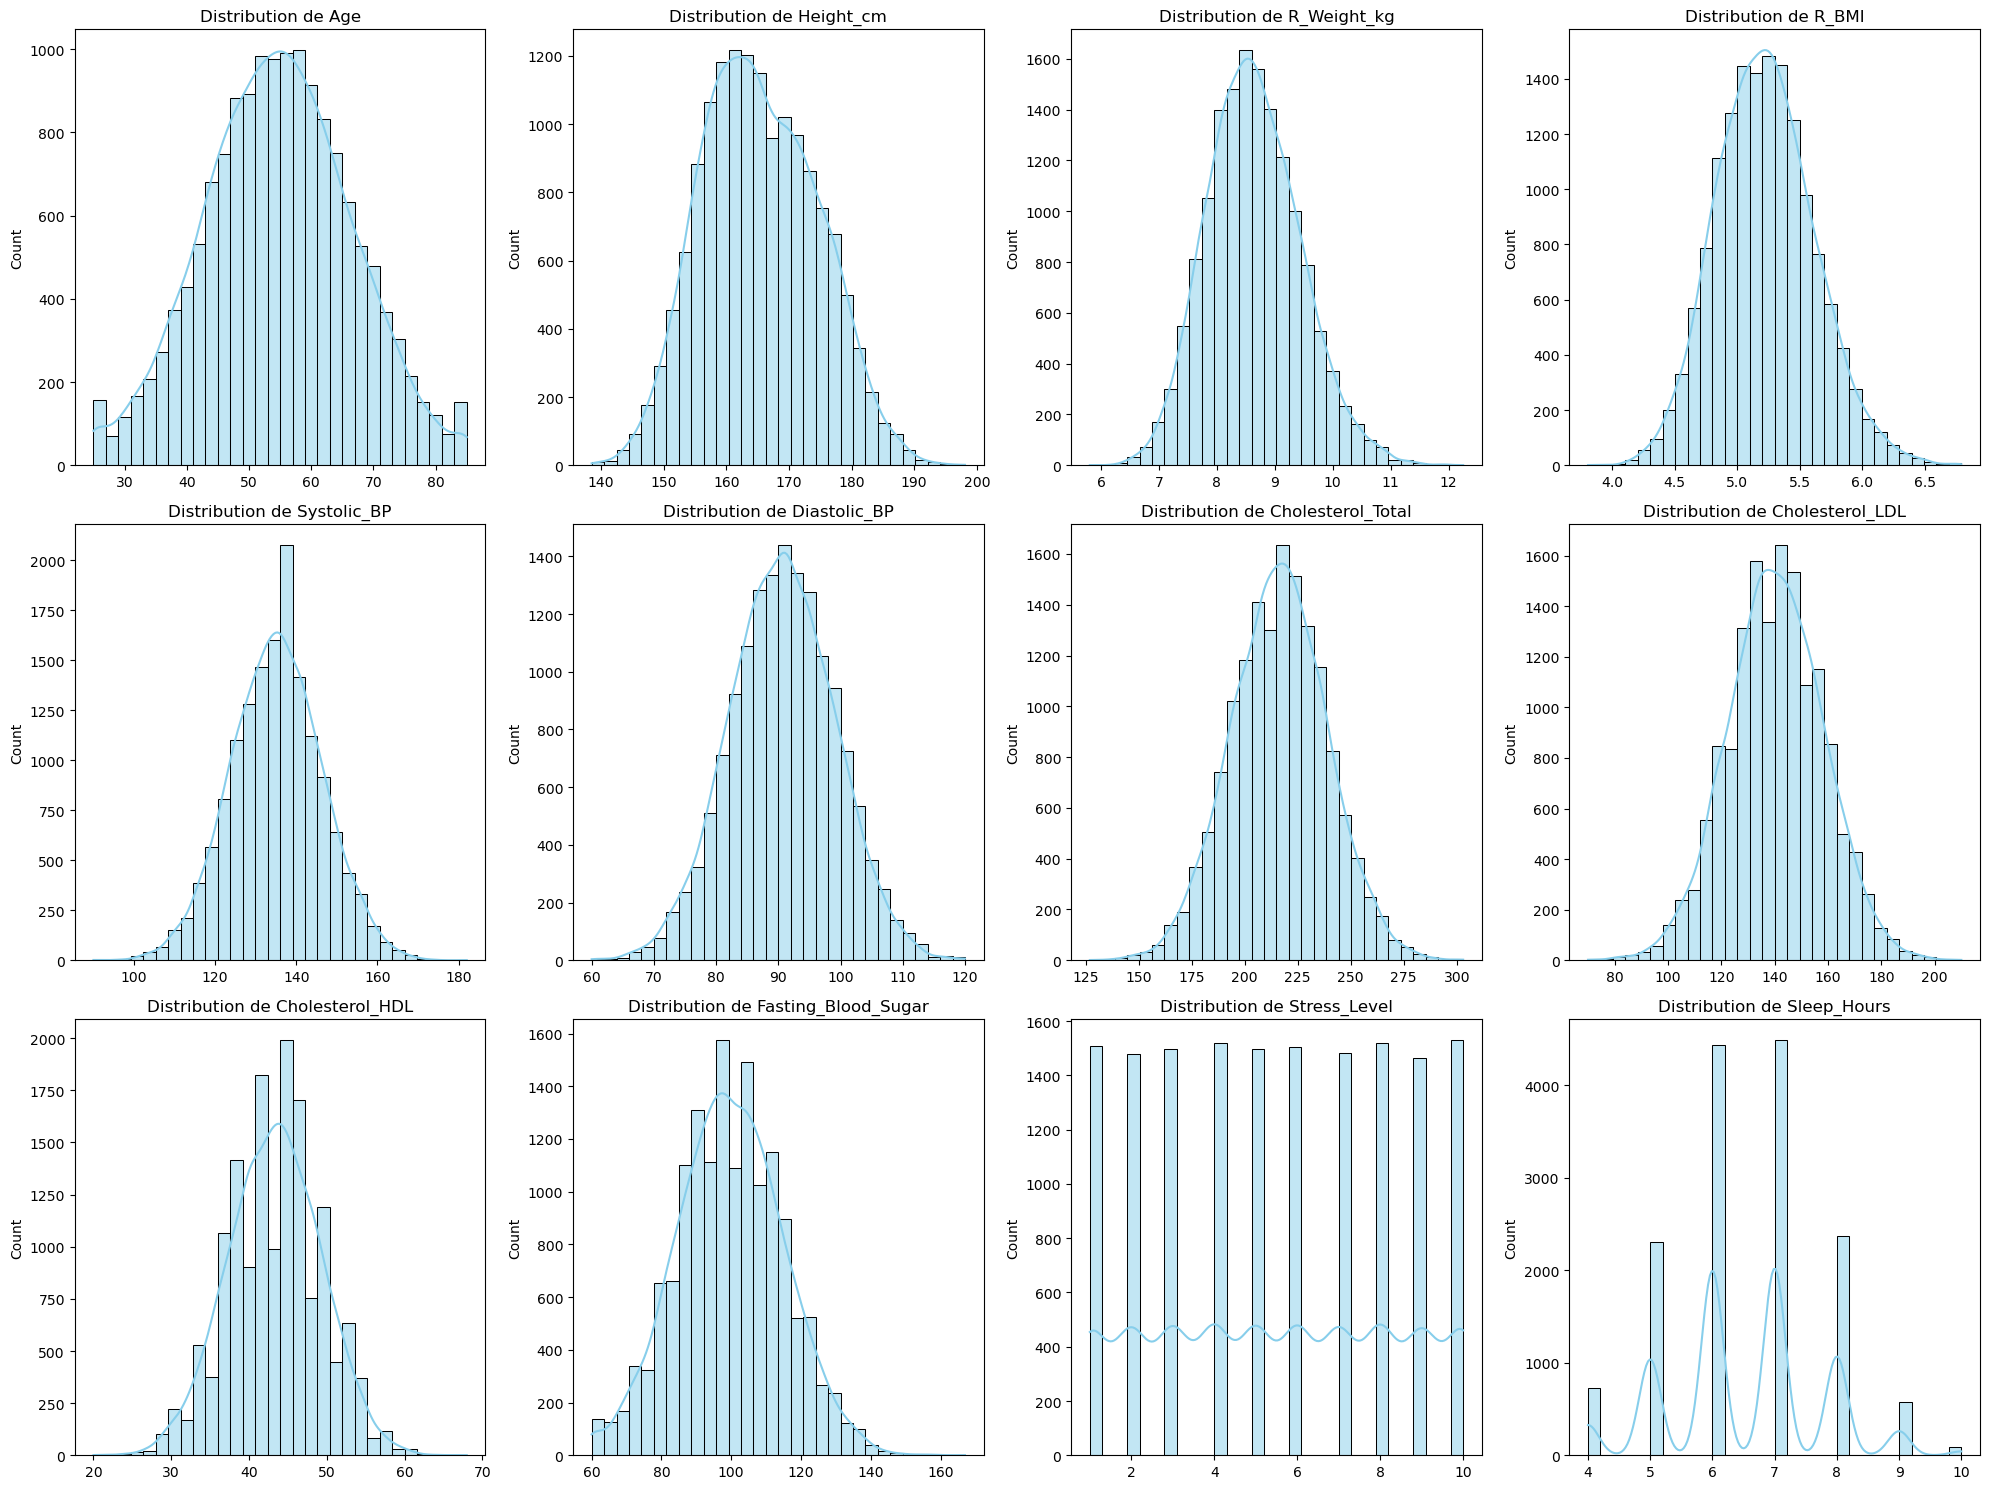

In [30]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten() 

for i, col in enumerate(variables):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', bins=30)
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

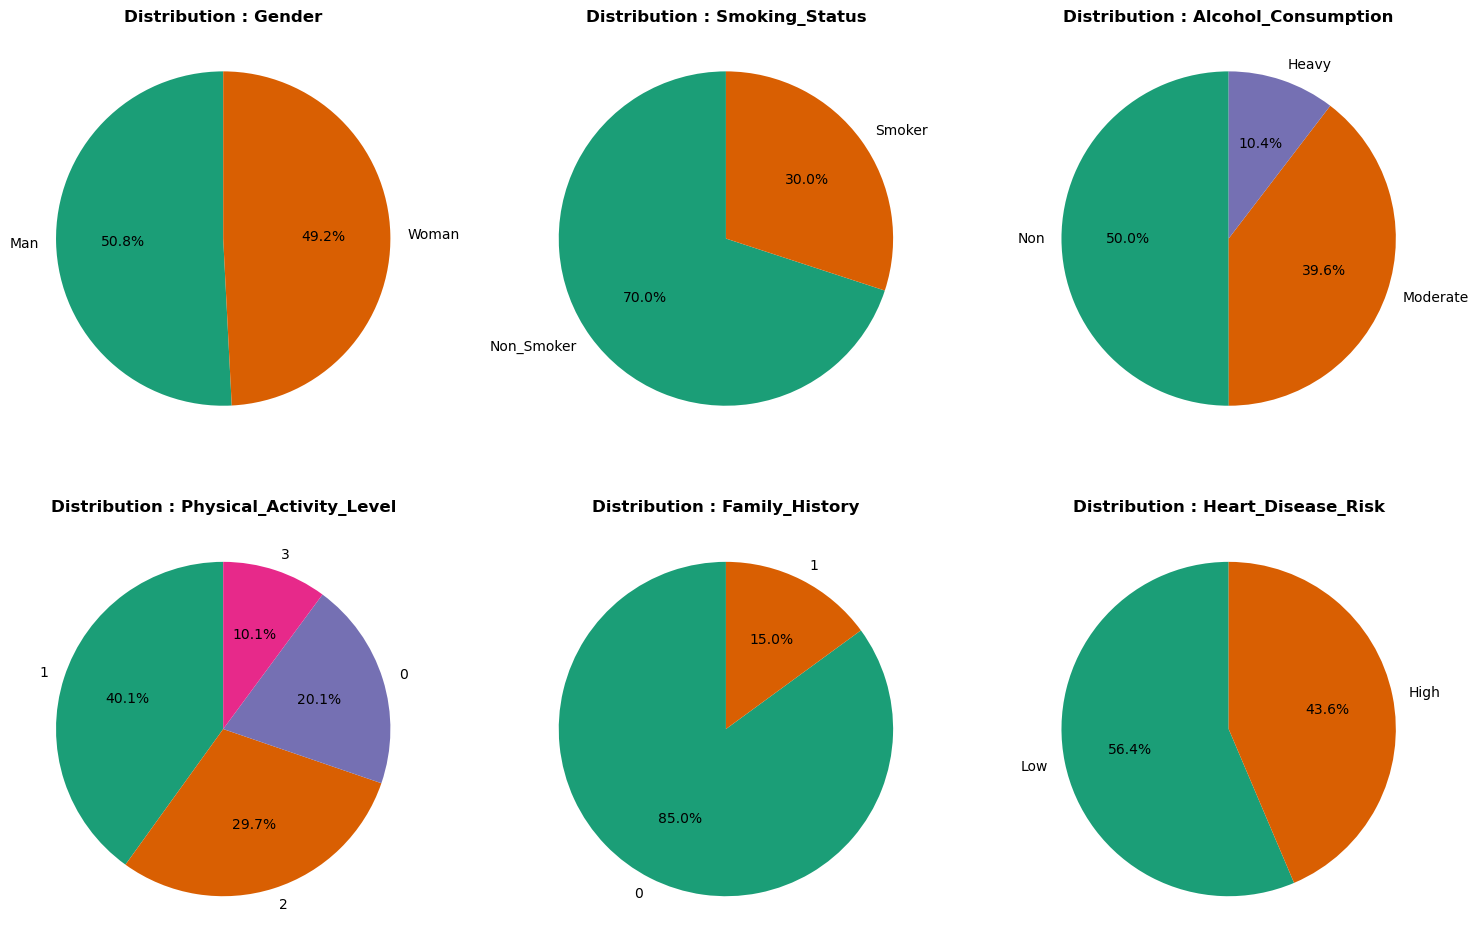

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

columns = [
    'Gender', 'Smoking_Status', 'Alcohol_Consumption', 
    'Physical_Activity_Level', 'Family_History', 'Heart_Disease_Risk'
]

axes_flat = axes.flatten()
cmap = plt.get_cmap('Dark2')

for i, col in enumerate(columns):
    counts = df[col].value_counts()
    colors = [cmap(i) for i in range(len(counts))]
    counts.plot(
        kind='pie', 
        ax=axes_flat[i], 
        autopct='%1.1f%%',
        colors=colors, 
        startangle=90,
        ylabel=''
    )
    axes_flat[i].set_title(f"Distribution : {col}", fontweight='bold')

plt.tight_layout()
plt.show()

## c. Bidimensional descriptive analysis of the data.

### i) C

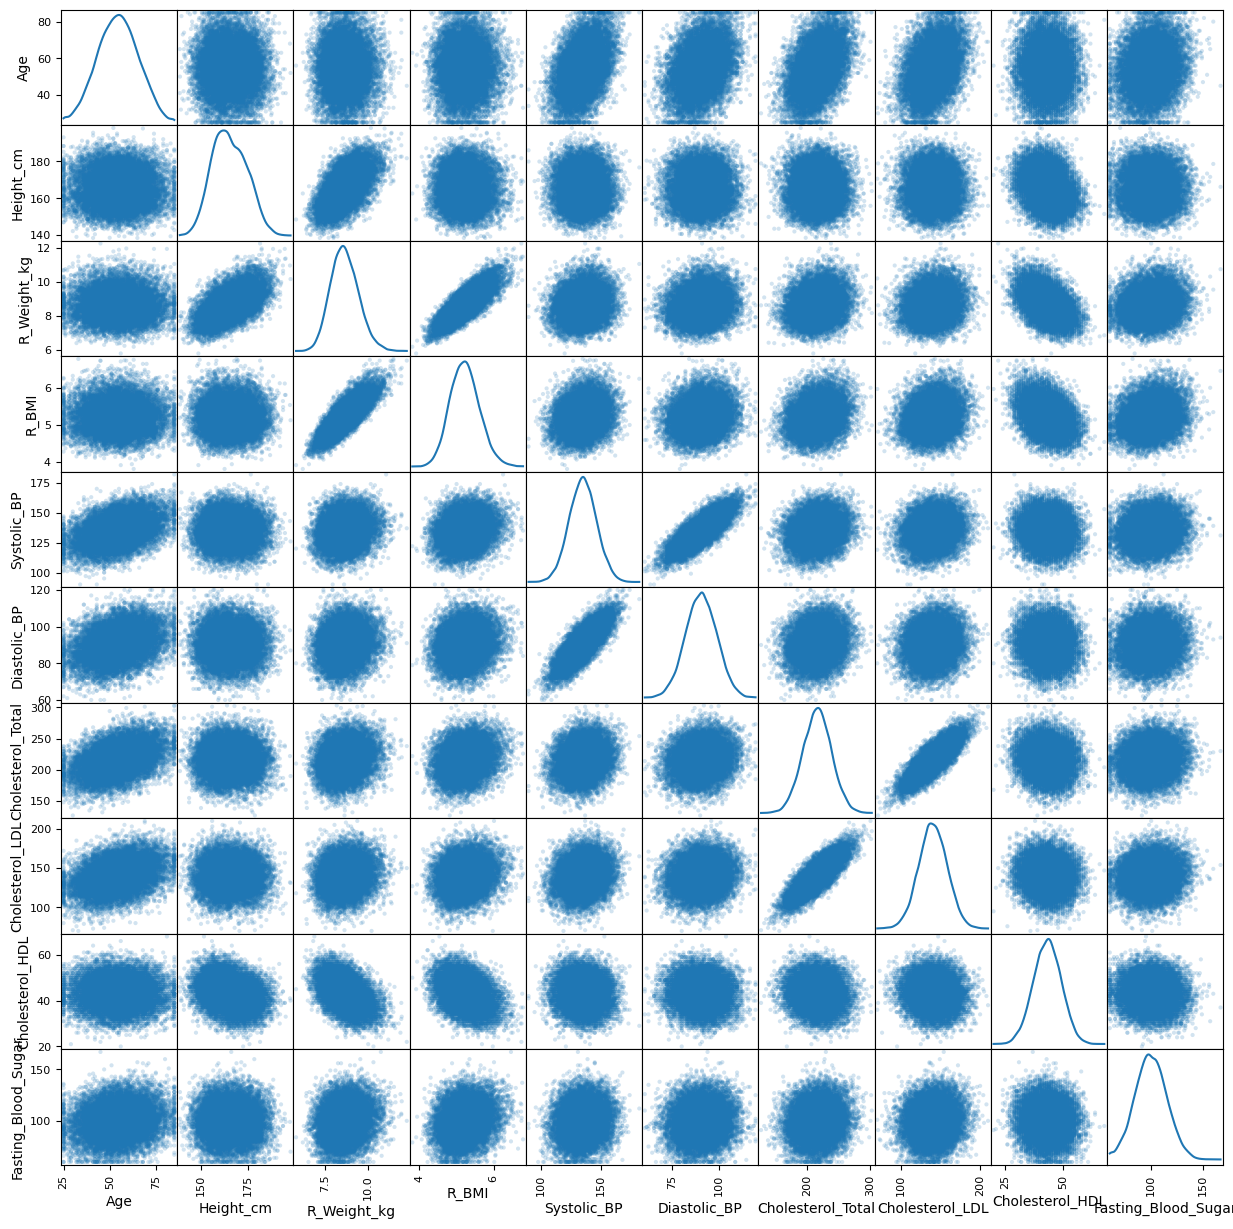

In [32]:
scatter_matrix(df[['Age', 'Height_cm', 'R_Weight_kg', 'R_BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL','Cholesterol_HDL', 'Fasting_Blood_Sugar']], alpha=0.2, 
               figsize=(15, 15), diagonal='kde')
plt.show()

On constate 3 dépendances linéaires positives :
- entre R_BMI et R_Weigth_kg
- entre Diastolic_BP et Systolic_BP
- entre Cholesterol Total et Cholesterol LDC
- entre R_Weigth et Height (plus faible)

Et négative :
- entre R_Weight et Cholesterol_HLD (faible)

C:\Users\alipe\AppData\Local\Temp\ipykernel_16532\4219307737.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=col, data=df, ax=axes[i], palette='viridis')
C:\Users\alipe\AppData\Local\Temp\ipykernel_16532\4219307737.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=col, data=df, ax=axes[i], palette='viridis')
C:\Users\alipe\AppData\Local\Temp\ipykernel_16532\4219307737.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=col, data=df, ax=axes[i], palette='viridis')
C:\Users\alipe\AppData\Local\Te

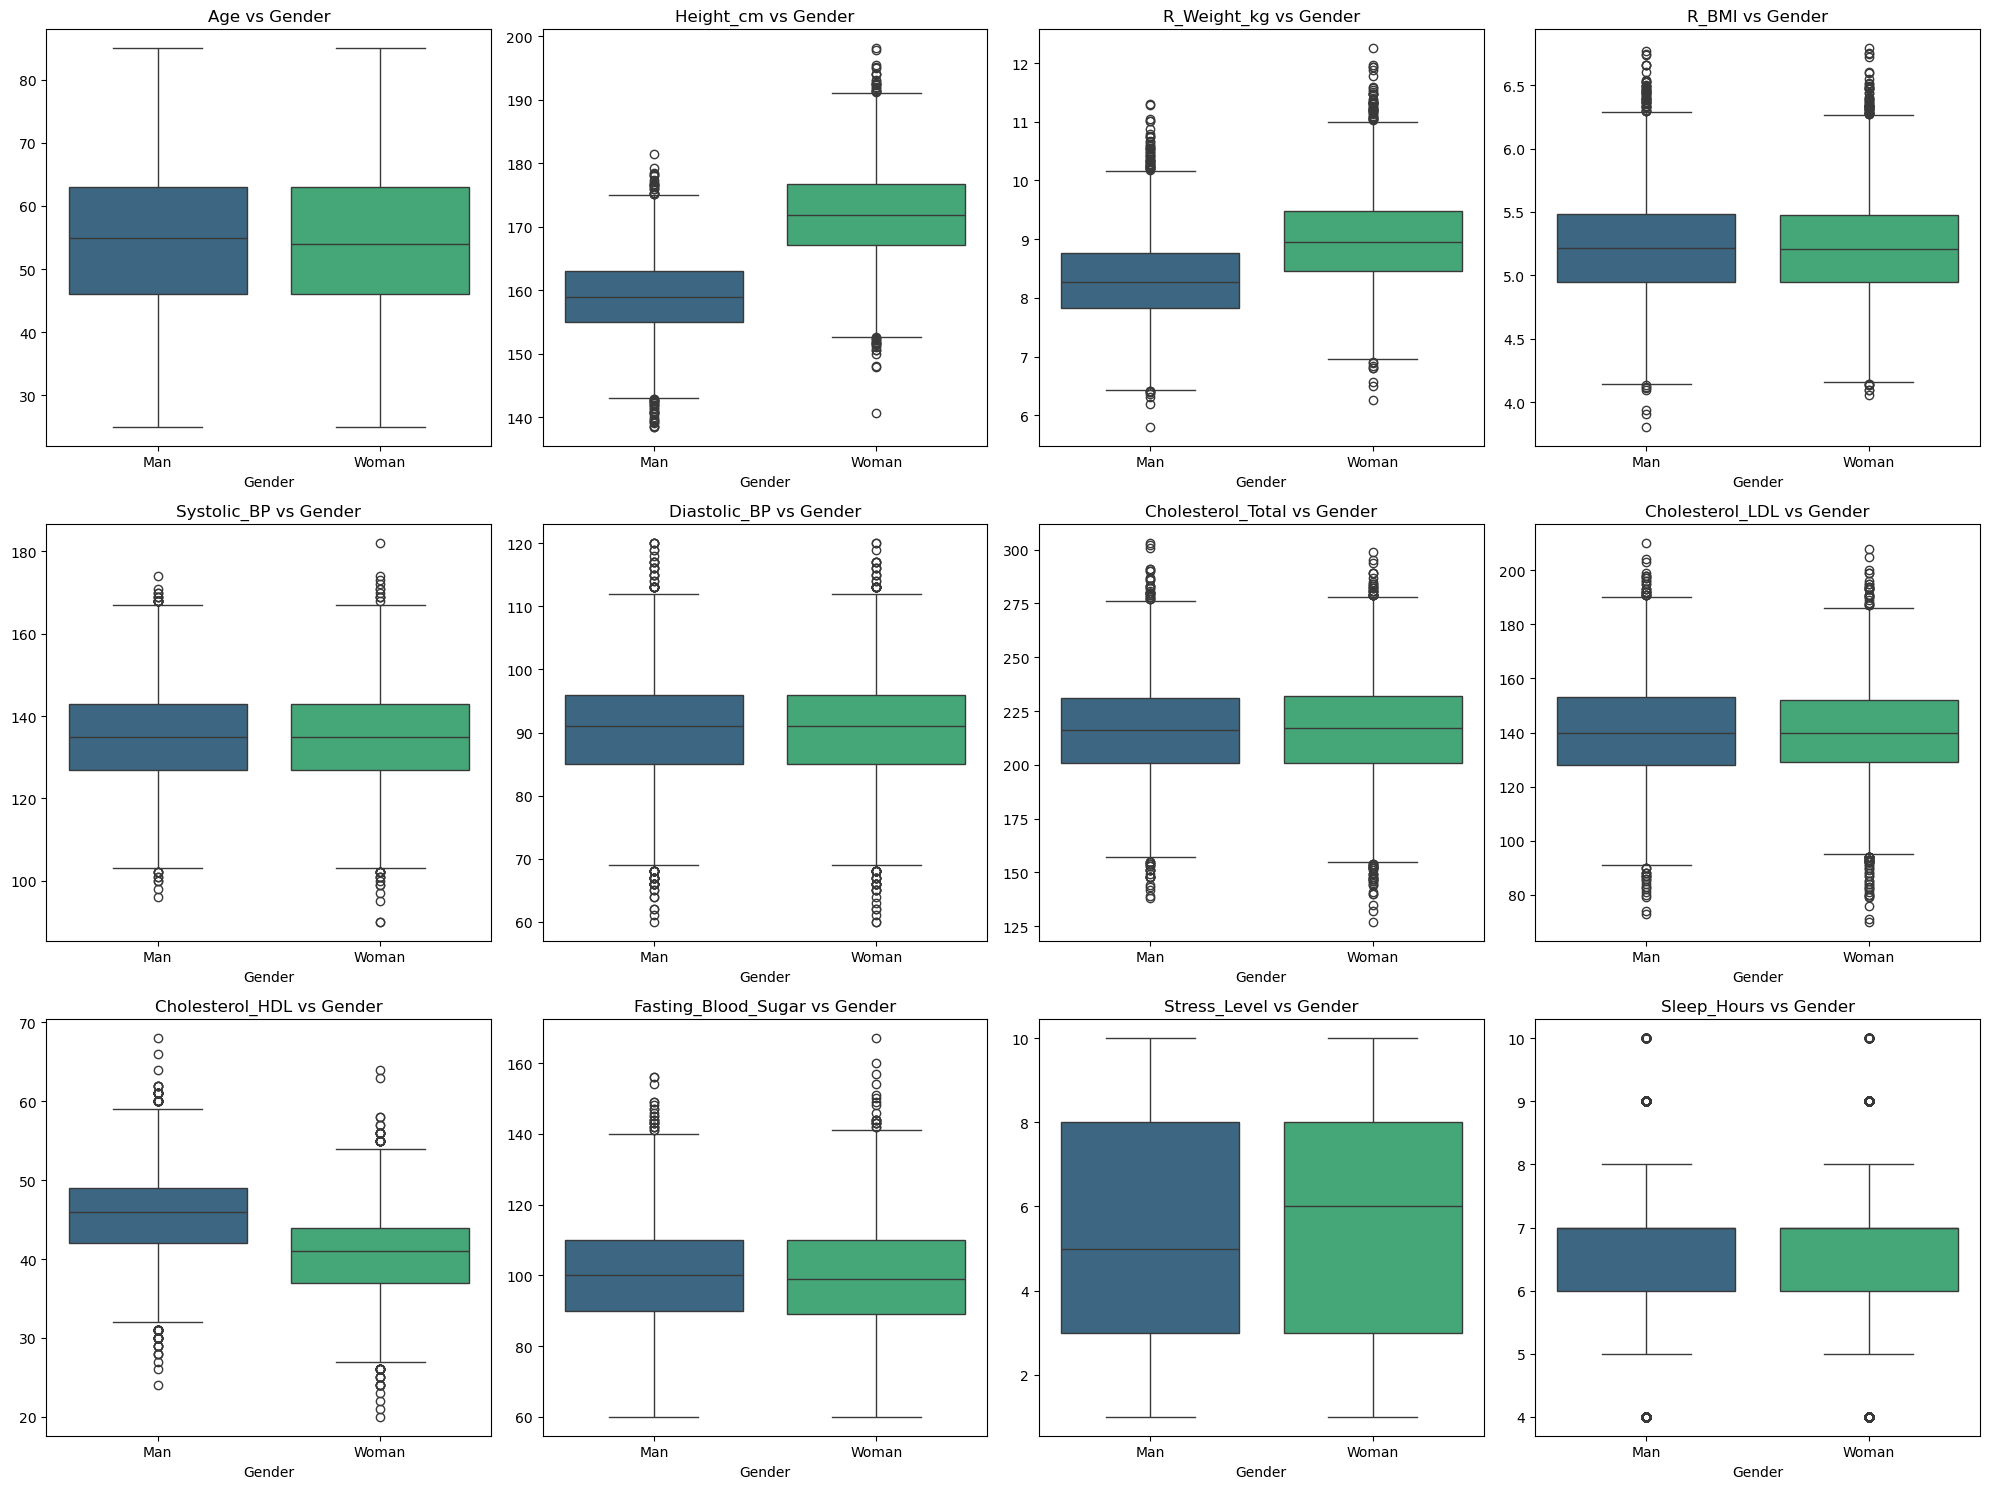

In [34]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(variables):
    sns.boxplot(x='Gender', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs Gender')
    axes[i].set_xlabel('Gender')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

C:\Users\alipe\AppData\Local\Temp\ipykernel_16532\826739182.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sleep_Hours', y=col, data=df, ax=axes[i], palette='viridis')
C:\Users\alipe\AppData\Local\Temp\ipykernel_16532\826739182.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sleep_Hours', y=col, data=df, ax=axes[i], palette='viridis')
C:\Users\alipe\AppData\Local\Temp\ipykernel_16532\826739182.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sleep_Hours', y=col, data=df, ax=axes[i], palette='viridis')
C:\Users\alipe\AppD

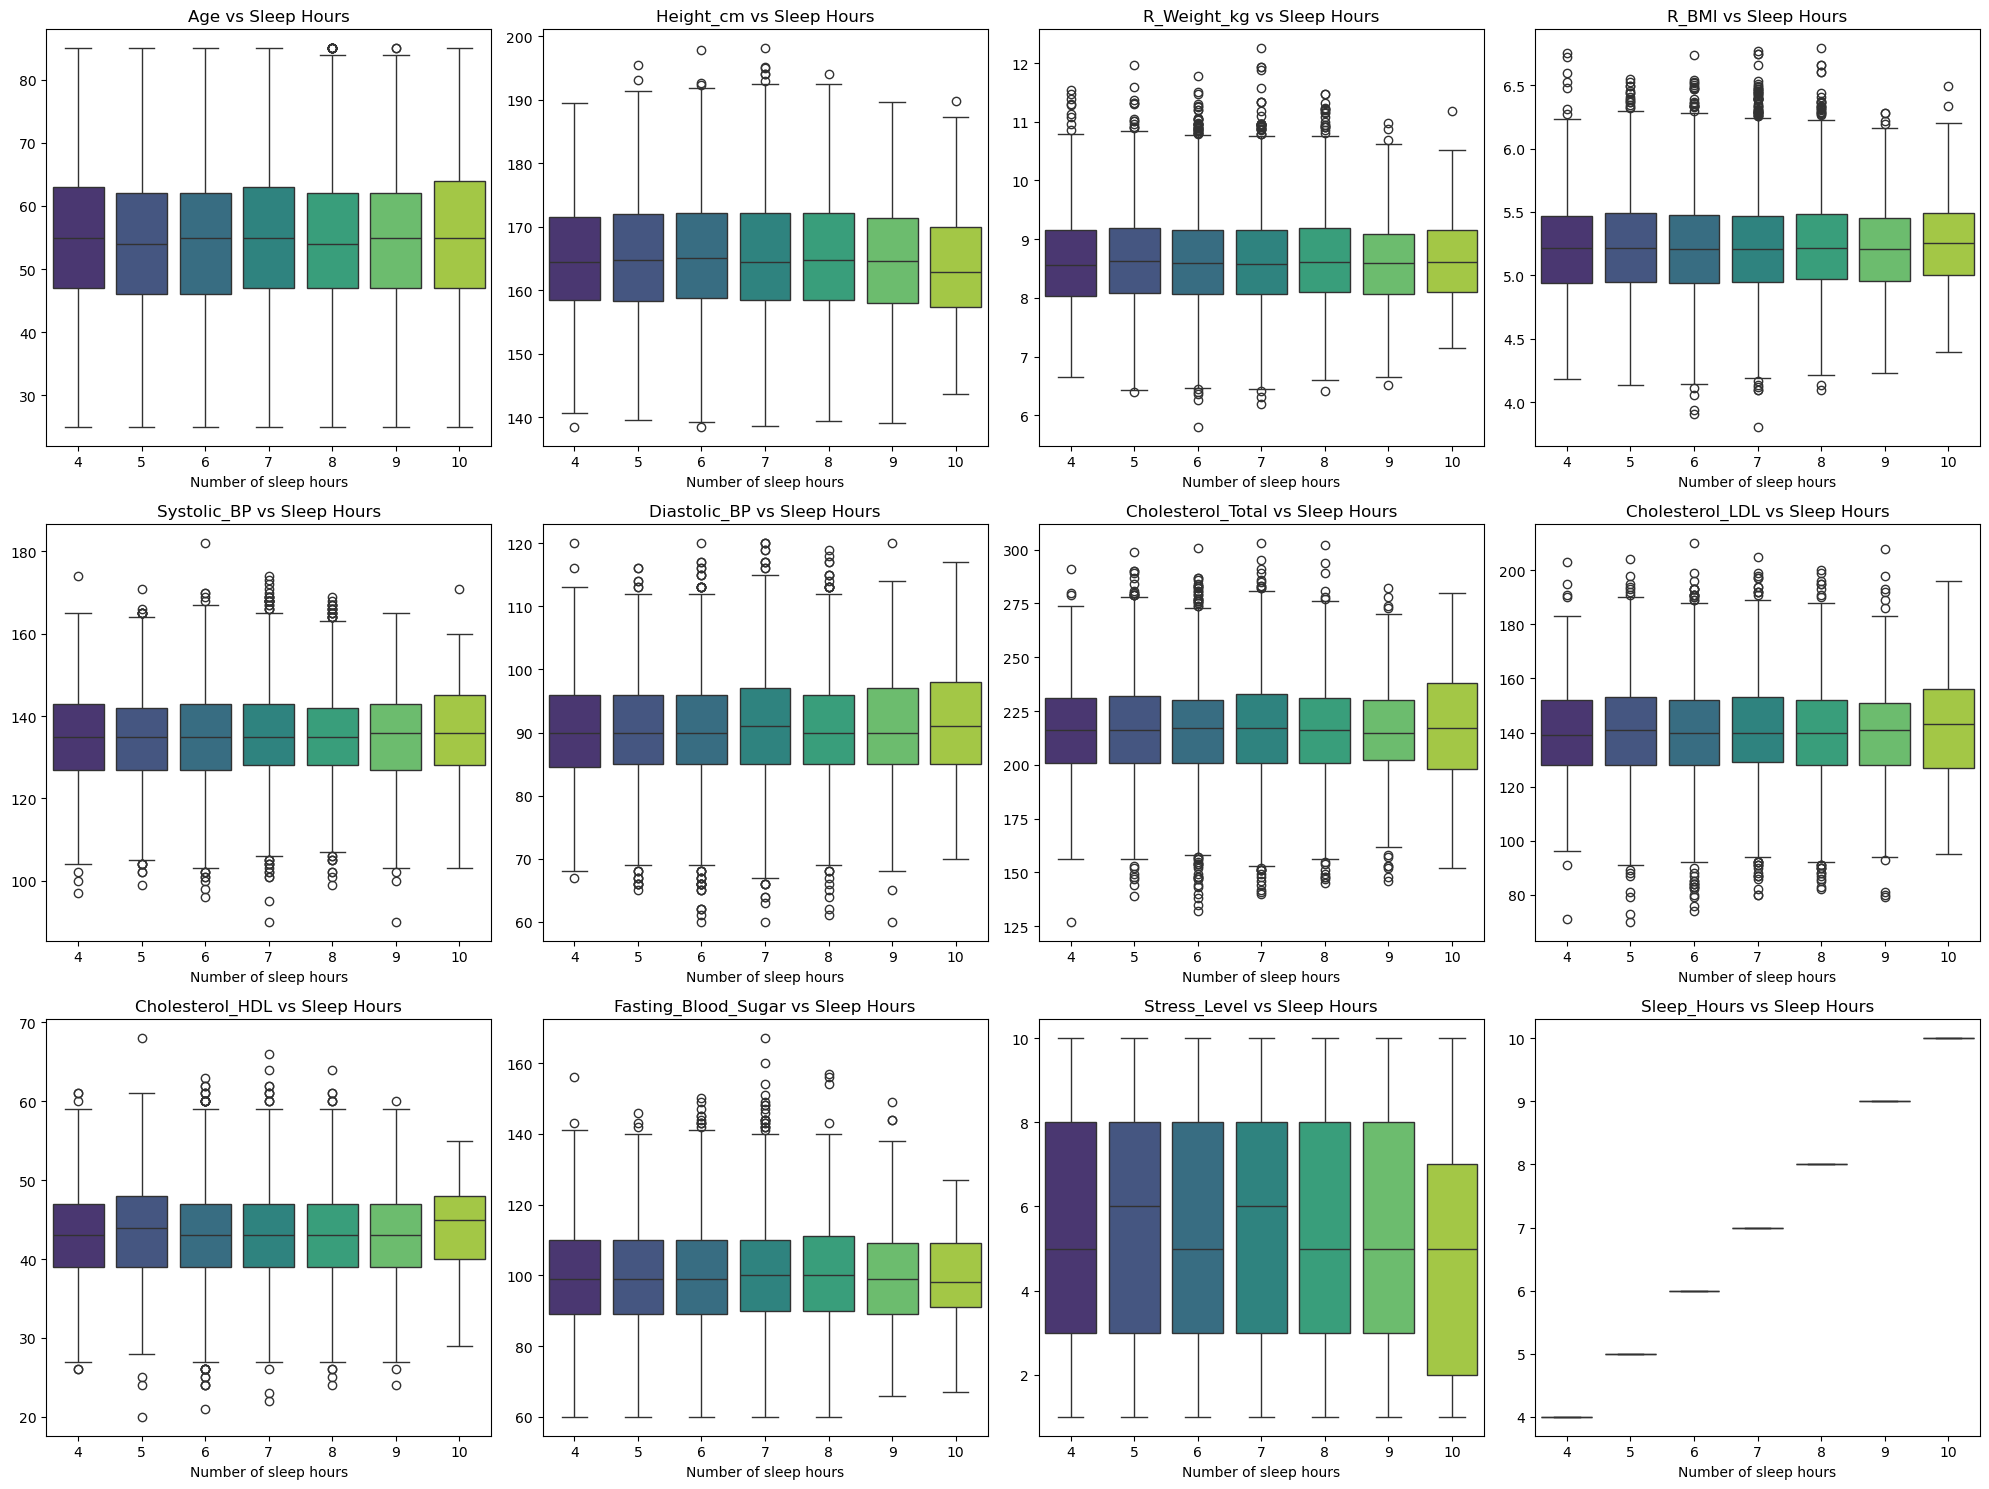

In [41]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(variables):
    sns.boxplot(x='Sleep_Hours', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs Sleep Hours')
    axes[i].set_xlabel('Number of sleep hours')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Diagramme interessant : Stress_level vs Sleep_hours

On les as tous tester et on a garder seulement ceux qui avaient des différences significatives en focntions des modalités.

from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
# réduction des variables
X=scale(df[['Age', 'Height_cm', 'R_Weight_kg', 'R_BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL','Cholesterol_HDL', 'Fasting_Blood_Sugar']])

In [ ]:
pca = PCA()
## Estimation, calcul des composantes principales
C = pca.fit(X).transform(X)
## Décroissance de la variance expliquée
plt.plot(pca.explained_variance_ratio_)
plt.show()

The elbow is identified at 3 (not clearly though), meaning that only 3 dimensions are necessary to explain the main part of the information.

In [ ]:
plt.boxplot(C[:,0:20])
plt.show()

La dimension 1 capte une grande partie de la variance, a partir de la dimension 5 on ne capte plus beaucoup de l'information. la dimension 1 explique beaucoup les outliers, la ou les points sont plus rapprochés ensuite. on partirait alors plus sur 5 dimensions. 